In [76]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron    # Used for simple linear classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [77]:
from tensorflow.keras.models import Sequential     # Sequential lets you build a neural network layer-by-layer in Keras.

from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them

from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting

from tensorflow.keras.utils import to_categorical     # converts numeric class labels into one-hot encoded format for training classification models


In [151]:
df = pd.read_csv("mnist_train.csv")

In [79]:
df

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [80]:
df_test

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [81]:
df.shape

(42000, 785)

In [82]:

df.columns

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='object', length=785)

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [84]:
df.isnull().sum()

,0
label,0
pixel0,0
pixel1,0
pixel2,0
pixel3,0
...,...
pixel779,0
pixel780,0
pixel781,0
pixel782,0


In [85]:
df.isnull().sum().sum()

np.int64(0)

In [86]:
#lets preprocess the data
X = df.drop("label",axis=1).values  #The .values code converts a Pandas Dataframe into a plain NumPy array. Machine learning libraries like Scikit-Learn need numbers in a fast matrix layout instead of a labeled table.
y = df["label"].values


In [87]:
# 80% used for training, 20% reserved for testing accuracy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [88]:
#to convert value b/w 0 and 1 we divide by 255 (0 black - 255 white)
X_train = X_train.astype("float32")/255.0 #This code performs data normalization on image datasets to scale pixel values from their original range of [0, 255] down to a standard range of [0.0, 1.0]. This is a standard preprocessing step in deep learning pipelines using frameworks like TensorFlow / Keras or PyTorch
X_test = X_test.astype("float32")/255.0

In [89]:
#reshape the data converting in 1D to send it to fully connected layer(ANN)
X_train_img = X_train.reshape(-1,28,28,) # Parameters: (-1: automatically calculate batch size, 28: height, 28: width,if usechoose color channel 1 for grey,3 for rgb)
X_test_img = X_test.reshape(-1,28,28,) #-1 (Dynamic Batch Size): Tells NumPy to automatically calculate this dimension based on the total number of samples in the dataset.28, 28 (Dimensions): Sets the spatial resolution of the image to 28 pixels high by 28 pixels wide.1 (Color Channels): Specifies a single color channel, indicating the input images are grayscale. Use 3 here for RGB color images.

In [90]:
X_train_img

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [95]:
y_train_cat = to_categorical(y_train,10) #to_categorical: A Keras utility function that performs one-hot encoding (output data to compare with input trained data(also in 0-1 form))
y_test_cat = to_categorical(y_test,10)  #Neural networks for classification output probabilities for each class. To compare the network's predictions against the true labels, the true labels must match that format. One-hot encoding transforms a single integer into an array of zeros and a single one.Visual ExampleIf you have an image of a dog labeled as class 3 out of 10 total classes (0 to 9), to_categorical converts it like this:Before (y_train): 3After (y_train_cat): [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

In [109]:
#it creates a simple Single-Layer Perceptron
perceptron = Sequential ([
    Flatten(input_shape=(28,28)),
    Dense(10,activation="softmax")
])

In [110]:
perceptron.compile(optimizer="sgd",loss="categorical_crossentropy",metrics=["accuracy"])  #This line of code configures a Keras or TensorFlow neural network model for training. It sets the Stochastic Gradient Descent (sgd) optimizer, uses categorical_crossentropy to measure multi-class prediction errors, and tracks accuracy as the evaluation metric.

In [111]:
history_percp = perceptron.fit(X_train_img,y_train_cat, epochs=5,
                               batch_size=32,validation_data=(X_test_img,y_test_cat),verbose=1) #perceptron.fit() returns a History object. Saving it to history_percp allows you to extract training loss and accuracy metrics to plot training vs. validation curves using matplotlib

Epoch 1/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7761 - loss: 0.9601 - val_accuracy: 0.8565 - val_loss: 0.6033
Epoch 2/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8699 - loss: 0.5299 - val_accuracy: 0.8749 - val_loss: 0.4864
Epoch 3/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8825 - loss: 0.4538 - val_accuracy: 0.8826 - val_loss: 0.4401
Epoch 4/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8898 - loss: 0.4167 - val_accuracy: 0.8886 - val_loss: 0.4124
Epoch 5/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8943 - loss: 0.3932 - val_accuracy: 0.8918 - val_loss: 0.3948


In [112]:
#see accuracy of this
accuracy_perc = perceptron.evaluate(X_test_img,y_test_cat,verbose=0)[1] # eg:-results[1] is Accuracy (91.45%) ,results[0] is Loss (0.3524)

In [113]:
accuracy_perc

0.891785740852356

In [114]:
#lets use multi-layered (ANN)
ann = Sequential([
    Flatten(input_shape=(28,28)), #Flatten the 2D input matrix (28x28 image) into a 1D vector (input layer)
    Dense(128,activation="relu"),
    Dense(64,activation="relu"),
    Dense(10,activation="softmax") # (Output layer)10 neurons using Softmax to output probability distributions
])

In [115]:
ann.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [116]:
history_ann = ann.fit(X_train_img,y_train_cat,epochs=5,batch_size=32,
                      validation_data=(X_test_img,y_test_cat),verbose=1)

Epoch 1/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 44s 5ms/step - accuracy: 0.9112 - loss: 0.3049 - val_accuracy: 0.9477 - val_loss: 0.1722
Epoch 2/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9598 - loss: 0.1309 - val_accuracy: 0.9621 - val_loss: 0.1251
Epoch 3/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9730 - loss: 0.0887 - val_accuracy: 0.9654 - val_loss: 0.1204
Epoch 4/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9805 - loss: 0.0638 - val_accuracy: 0.9676 - val_loss: 0.1097
Epoch 5/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9837 - loss: 0.0518 - val_accuracy: 0.9661 - val_loss: 0.1065


In [118]:
accuracy_ann = ann.evaluate(X_test_img , y_test_cat ,verbose=0) [1]

In [119]:
accuracy_ann

0.9660714268684387

In [120]:
#from now lets start the CNN


In [125]:
#reshape in 4D input for CNN
X_train_cnn = X_train.reshape(-1,28,28,1) # 1 for greyscale channel and 3 for rgb
X_test_cnn = X_test.reshape(-1,28,28,1)

In [126]:
cnn = Sequential([
    Conv2D(32,kernel_size=(3,3),activation="relu",input_shape=(28,28,1)),   # First Convolutional Layer: Extracts 32 low-level feature maps (edges, lines) using 3x3 filters
                                                                            # Input shape is (28, 28, 1) for 28x28 grayscale images
    MaxPooling2D(pool_size=(2,2)),                                          # First Max Pooling Layer: Downsamples spatial dimensions by half (from 26x26 to 13x13)
                                                                            # Reduces parameter count and computation while retaining dominant feature

    Conv2D(64,kernel_size=(3,3),activation="relu"),                         #Second Convolutional Layer: Learns 64 higher-level, complex spatial patterns (shapes, curves)
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),                                                              #Flatten Layer: Unrolls 3D feature maps (5x5x64) into a single 1D vector (1600 elements)
                                                                            #Required to pass data into standard fully connected Dense layer
    Dense(128,activation="relu"),                                           #Fully Connected Dense Layer: Combines extracted features with 128 neurons for classification
    Dropout(0.5),                                                           #Dropout Layer: Randomly deactivates 50% of neurons during training to prevent overfitting
    Dropout(0.5),
    Dense(10,activation="softmax")                                          # 8. Output Layer: Outputs 10 final probability scores (summing to 1.0) for classes 0-9
  ])

In [129]:
cnn.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [130]:
history_cnn = cnn.fit(X_train_cnn,y_train_cat,epochs=5 ,batch_size=32,
                           validation_data=(X_test_cnn,y_test_cat),verbose=1)

Epoch 1/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 31s 28ms/step - accuracy: 0.8515 - loss: 0.4635 - val_accuracy: 0.9743 - val_loss: 0.0867
Epoch 2/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 30s 28ms/step - accuracy: 0.9423 - loss: 0.1885 - val_accuracy: 0.9825 - val_loss: 0.0555
Epoch 3/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 48s 45ms/step - accuracy: 0.9551 - loss: 0.1444 - val_accuracy: 0.9844 - val_loss: 0.0494
Epoch 4/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 62s 27ms/step - accuracy: 0.9626 - loss: 0.1200 - val_accuracy: 0.9874 - val_loss: 0.0445
Epoch 5/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.9688 - loss: 0.1033 - val_accuracy: 0.9876 - val_loss: 0.0395


In [131]:
accuracy_cnn = cnn.evaluate(X_test_cnn,y_test_cat,verbose=0)[1]

In [132]:
accuracy_cnn

0.9876190423965454

In [133]:

def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()


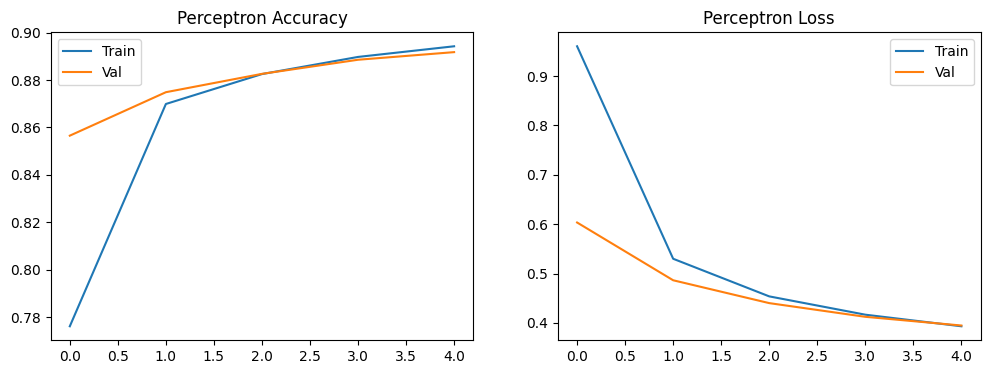

In [136]:
plot_training(history_percp , "Perceptron")

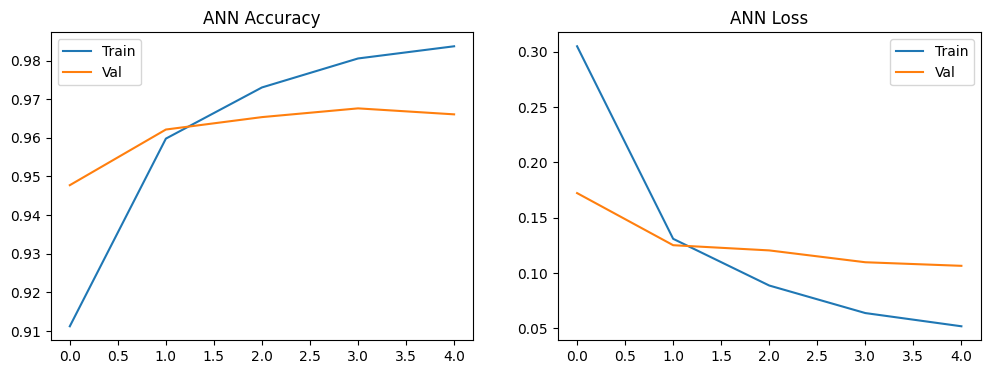

In [137]:
plot_training(history_ann , "ANN")

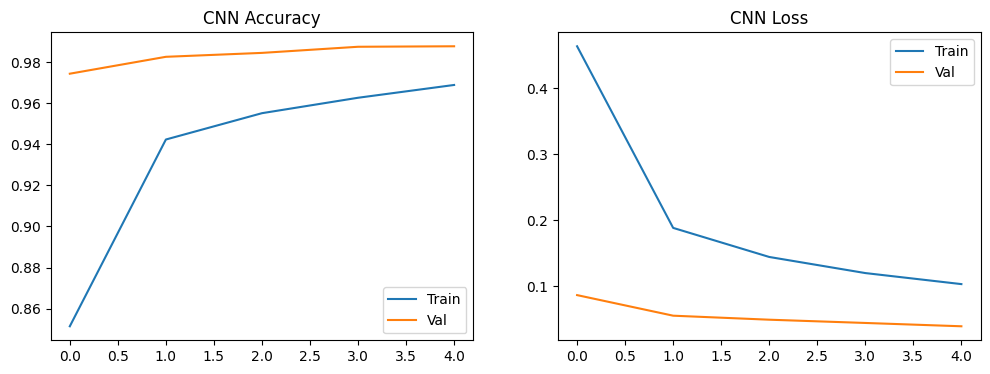

In [138]:
plot_training(history_cnn , "CNN")

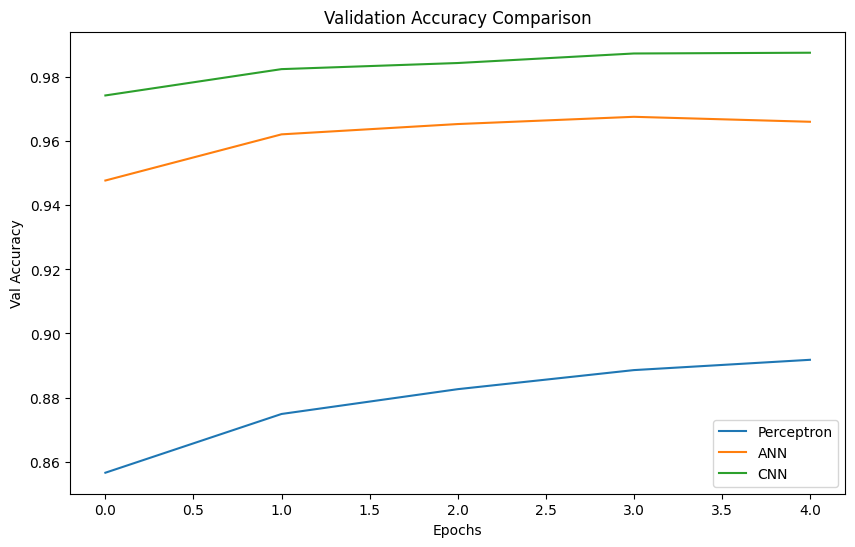

In [139]:

plt.figure(figsize=(10,6))
plt.plot(history_percp.history['val_accuracy'], label="Perceptron")
plt.plot(history_ann.history['val_accuracy'], label="ANN")
plt.plot(history_cnn.history['val_accuracy'], label="CNN")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()


In [140]:

def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


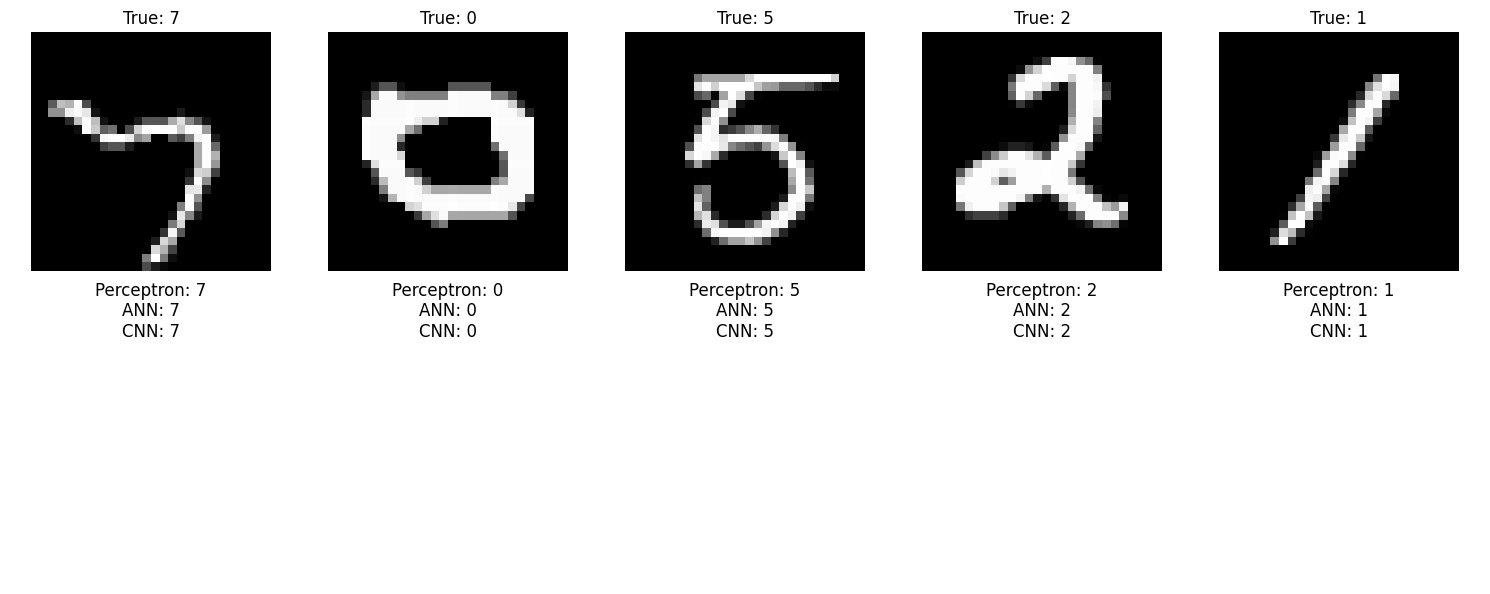

In [144]:
show_side_by_side([perceptron, ann, cnn], ["Perceptron", "ANN", "CNN"], X_test_img, X_test_cnn, y_test, 5)

263/263 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step


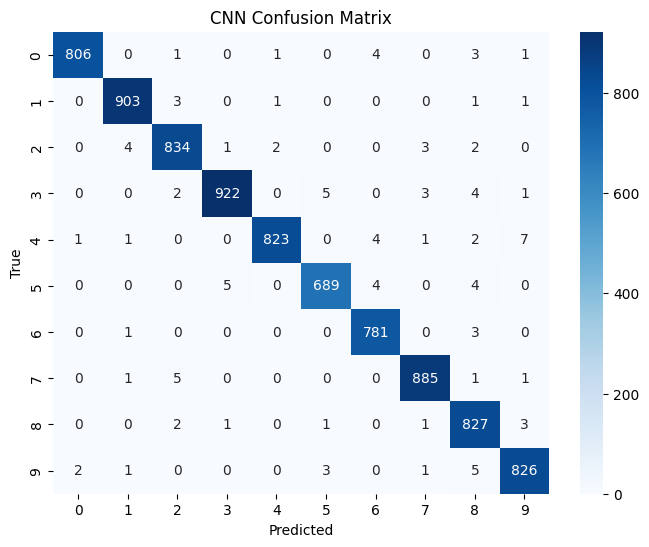

In [145]:

y_pred_cnn = np.argmax(cnn.predict(X_test_cnn), axis=1)
cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

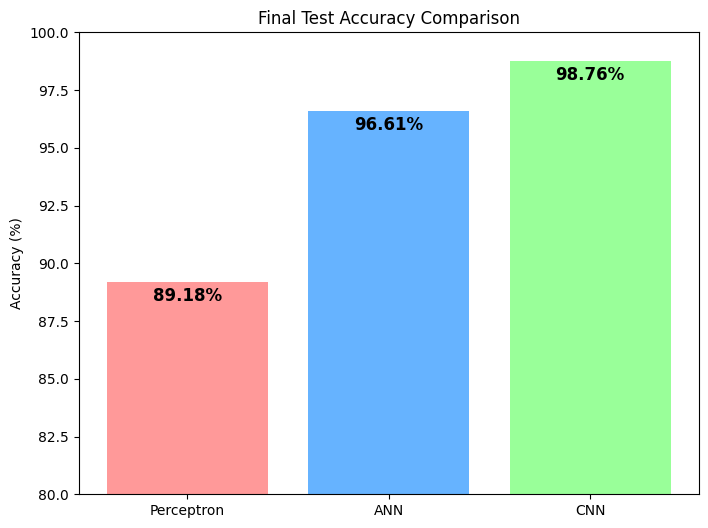

In [150]:
final_accuracy = [accuracy_perc*100, accuracy_ann*100, accuracy_cnn*100]
models = ["Perceptron", "ANN", "CNN"]

plt.figure(figsize=(8,6))
bars = plt.bar(models, final_accuracy, color=['#ff9999','#66b3ff','#99ff99'])
plt.title("Final Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
for bar, acc in zip(bars, final_accuracy):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()-1, f"{acc:.2f}%",
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.ylim(80, 100)
plt.show()